In [1]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import onnxruntime as ort
import pandas as pd
from PIL import Image
from tqdm import tqdm

import sys
sys.path.append('../')
from solar_irradiance.datamodules.sun_mask import SunMask

In [2]:
irr_df = pd.read_csv('../data/Prepared/cleaned_irradiance.csv', parse_dates=['datetime'], index_col='datetime')
irr_df.index = pd.to_datetime(irr_df.index)

In [3]:
irr_df.head()

,Unnamed: 0,irradiance,image_name
datetime,,,
2014-01-17 15:30:00,22050,2.37,20140117_153000.jpg
2014-01-17 15:31:00,22051,2.97,20140117_153100.jpg
2014-01-17 15:33:00,22053,4.57,20140117_153300.jpg
2014-01-17 15:34:00,22054,5.81,20140117_153400.jpg
2014-01-17 15:35:00,22055,7.81,20140117_153500.jpg


In [4]:
irr_df.reset_index().datetime.dt

In [5]:
irr_df.reset_index().groupby([
    irr_df.reset_index().datetime.dt.year,
    irr_df.reset_index().datetime.dt.month, 
    irr_df.reset_index().datetime.dt.day,
]).count().sort_values(by='image_name')

datetime  Unnamed: 0  irradiance  image_name
datetime datetime datetime                                              
2015     11       18               1           1           1           1
                  20               1           1           1           1
                  25               1           1           1           1
         12       2                1           1           1           1
2014     10       24               1           1           1           1
...                              ...         ...         ...         ...
         7        4              639         639         639         639
         5        11             640         640         640         640
         6        22             650         650         650         650
                  29             653         653         653         653
                  21             675         675         675         675

[951 rows x 4 columns]

In [6]:
image_dir = '20140621_22'
image_list = sorted(list(Path(image_dir).glob('*.jpg')))

In [7]:
model_path = Path('../models/r3d_18_sun_mask.onnx')
sess = ort.InferenceSession(str(model_path), providers=['CPUExecutionProvider'])

inputs = [l.name for l in sess.get_inputs()]
shapes = [l.shape for l in sess.get_inputs()]
print(f"Model inputs: {inputs}")
print(f"Model inputs' shapes: {shapes}")

Model inputs: ['image_input', 'irradiance_history']
Model inputs' shapes: [[1, 4, 4, 384, 384], [1, 4]]


In [8]:
def preprocess(img_data: np.ndarray) -> np.ndarray:
    mean_vec = np.array([0.485, 0.456, 0.406])
    stddev_vec = np.array([0.229, 0.224, 0.225])

    img_data = (img_data / 255 - mean_vec) / stddev_vec
    img_data = np.transpose(img_data, (2, 0, 1))

    return img_data.astype("float32")

In [9]:
MAX_IRRADIANCE = 1366.0
LATITUDE = 38.642
LONGITUDE = -121.148
CAMERA_ORIENTATION_COMPENSATION = 165
FOCAL_LENGTH = 0.48
sun_mask_gen = SunMask(LATITUDE, LONGITUDE, CAMERA_ORIENTATION_COMPENSATION, FOCAL_LENGTH)

gt_irradiances = []
predicted_irradiances = []
persistent_model_irradiances = []

for image_path in tqdm(image_list[15:]):
    t = irr_df[irr_df['image_name'] == image_path.name].index
    
    t_m15 = t - pd.Timedelta(minutes=15)
    t_m10 = t - pd.Timedelta(minutes=10)
    t_m5 = t - pd.Timedelta(minutes=5)
    t_p15 = t + pd.Timedelta(minutes=15)
    
    try:
        if all(map(lambda x: not irr_df.loc[x].empty, [t_m15, t_m10, t_m5, t, t_p15])):
            source_irradiances = []
            source_images = []        
            for _t in [t_m15, t_m10, t_m5, t]:
                row = irr_df.loc[_t]
                irradiance = row['irradiance'].values[0] / MAX_IRRADIANCE
                image_path = Path(image_dir, row['image_name'].values[0])
                source_image = np.asarray(Image.open(image_path))
                source_image = cv2.resize(source_image, (384, 384))
                
                input_data = preprocess(source_image)

                sun_mask = sun_mask_gen(image_shape=source_image.shape, timestamp=image_path.name[:15])
                input_data = np.concatenate([input_data, np.transpose(sun_mask, (2, 0, 1))], axis=0)

                source_irradiances.append(irradiance)
                source_images.append(input_data)
                
            image_input = np.expand_dims(np.transpose(source_images, (1, 0, 2, 3)), axis=0).astype(np.float32)
            irradiance_input = np.expand_dims(source_irradiances, axis=0).astype(np.float32)
            
            predicted_irradiance = output = sess.run(None, {
                inputs[0]: image_input,
                inputs[1]: irradiance_input,
            })[0][0][0]
            predicted_irradiances.append(predicted_irradiance * MAX_IRRADIANCE)

            row = irr_df.loc[t]
            irradiance = row['irradiance']
            persistent_model_irradiances.append(irradiance)

            row = irr_df.loc[t_p15]
            irradiance = row['irradiance']
            gt_irradiances.append(irradiance)
    except KeyError:
        continue

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1750/1750 [15:49<00:00,  1.84it/s]


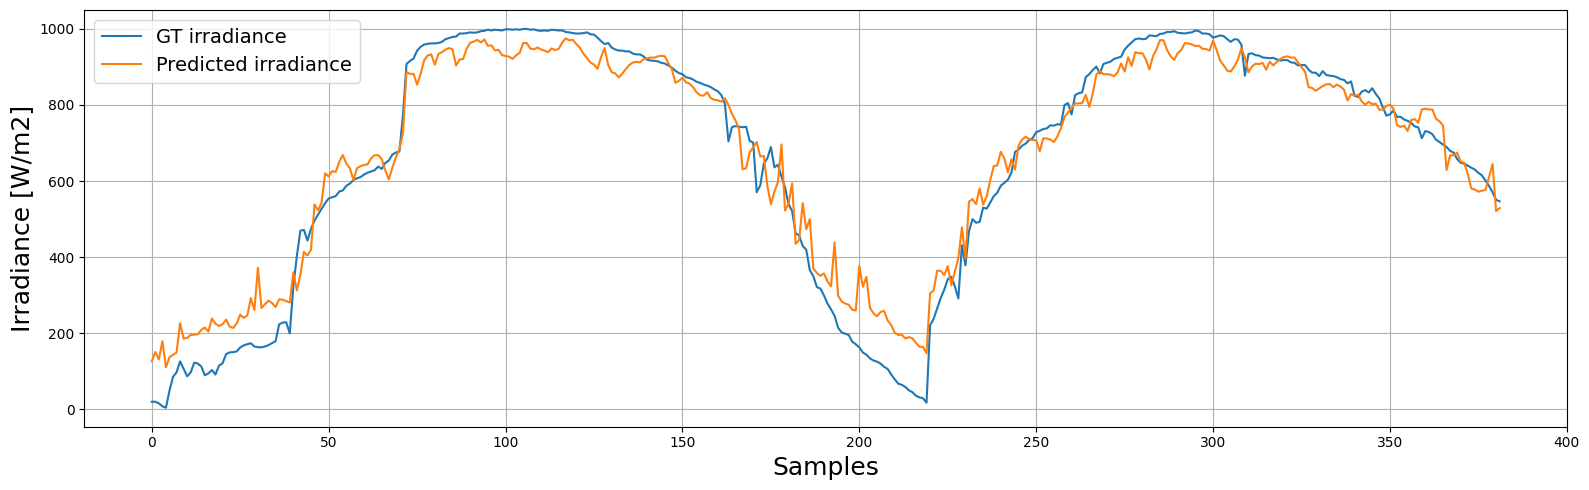

In [16]:
fig = plt.figure(figsize=(16, 5))

plt.plot(gt_irradiances[50:], label='GT irradiance')
# plt.plot(persistent_model_irradiances, label='Persistent Model')
plt.plot(predicted_irradiances[50:], label='Predicted irradiance')
plt.grid(True)
plt.legend(fontsize=14)
plt.ylabel('Irradiance [W/m2]', fontsize=18)
plt.xlabel('Samples', fontsize=18)
plt.tight_layout()
# plt.show()
plt.savefig(f'irradiance_prediction_{image_dir}.png', dpi=300)